# Decision Tree Regressor - Model Development Workflow

> **MLCourse · Machine Learning · supervised · regression**

## What you'll learn

1. Loading and sampling a real dataset (California housing) the reproducible way.
2. Why an **unpruned tree** betrays you: perfect training score, mediocre test score.
3. Sweeping `max_depth` with **5-fold cross-validation** to find the sweet spot.
4. Pruning with `ccp_alpha` - the cost-complexity path, and how to pick along it.
5. Reading **feature importances**: what the finished tree actually looks at.

In [1]:
# Setup cell: libraries, reproducibility, plot styling (run me first).
try:  # enable inline plotting when executed inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # same effect as the %matplotlib magic
except NameError:  # plain-script execution has no IPython shell - nothing to configure
    pass

import numpy as np                  # vector maths + RNG seeding
import pandas as pd                 # tables for data handling
import matplotlib.pyplot as plt     # figure control
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split, cross_val_score  # splitting + CV scoring
from sklearn.tree import DecisionTreeRegressor                         # the model of this chapter
from sklearn.metrics import mean_squared_error, r2_score               # regression metrics

np.random.seed(42)                  # global reproducibility for numpy randomness
sns.set_theme()                     # clean default plot styling
plt.rcParams["figure.dpi"] = 100    # crisp-but-light figures

## 1. Business framing & data

**Question:** given census-block stats (income, house age, location...), predict
median house value - useful for appraisal triage and market screening.

The full California table has 20,640 rows. We take a fixed random sample of
5,000 so the cross-validation sweeps below stay fast; with `random_state=42`
everyone gets the identical sample.

In [2]:
from pathlib import Path  # robust filesystem paths

def find_data_dir():
    # Climb up from the notebook's folder until inside the course's '02_machine_learning'
    # directory, then target its shared 'data' sub-folder.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # one level up per loop iteration
    return here / "data"

DATA_DIR = find_data_dir()          # same resolution logic used by every MLCourse notebook

def load_california():
    # Cache-once helper: derive the CSV from sklearn's bundled loader only if absent.
    csv_path = DATA_DIR / "california_housing.csv"
    if not csv_path.exists():       # first encounter: build the local cache
        from sklearn.datasets import fetch_california_housing   # ships inside scikit-learn
        frame = fetch_california_housing(as_frame=True).frame    # features + target as one DataFrame
        frame.to_csv(csv_path, index=False)                  # persist for all future runs/notebooks
        print(f"Created cache -> {csv_path}")
    return pd.read_csv(csv_path)    # subsequent runs just read the CSV

housing_full = load_california()    # full 20,640-row table
print("full shape:", housing_full.shape)

housing = housing_full.sample(n=5000, random_state=42).reset_index(drop=True)  # fixed 5k sample
target = "MedHouseVal"              # median house value, units of $100,000 (capped at 5.0)
print("sample shape:", housing.shape)
housing.head()                      # quick structural peek at columns and scales

full shape: (20640, 9)
sample shape: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


### Quick EDA before modelling

Two things to check every time: what the **target distribution** looks like
(skew, caps, outliers) and which features correlate with it / each other.
💡 Notice `MedHouseVal` is hard-capped at \$500k (value 5.0) - trees will
happily learn that cliff, linear models would struggle.

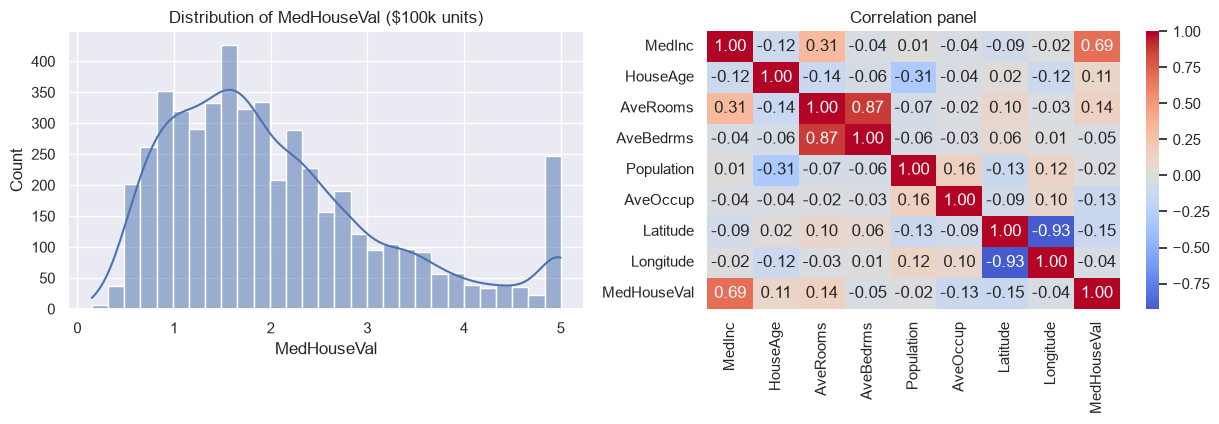

0 missing values in total


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))      # side-by-side diagnostic panel
sns.histplot(housing[target], kde=True, ax=axes[0])       # target histogram + smooth density
axes[0].set_title(f"Distribution of {target} ($100k units)")  # note the pile-up at the cap
sns.heatmap(housing.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[1])        # pairwise correlations for orientation
axes[1].set_title("Correlation panel")
plt.tight_layout()                   # prevent axis labels overlapping between panels
plt.show()

print(housing.isna().sum().sum(), "missing values in total")  # audit: this dataset ships clean

## 2. Train/test split

We hold out 20% of rows as a **test set** that no tuning step may touch.
All auditioning (depth sweep, alpha path) happens via cross-validation *on the
training portion only*; the test set answers exactly once, at the end, for the
chosen model. ⚠️ Tuning on the test set silently turns it into training data.

In [4]:
features = [c for c in housing.columns if c != target]           # every column except the label
X_train, X_test, y_train, y_test = train_test_split(
    housing[features], housing[target],
    test_size=0.2, random_state=42,                              # fixed shuffle → reproducible split
)
print(f"train: {X_train.shape}   test: {X_test.shape}")          # confirm the carve-up

train: (4000, 8)   test: (1000, 8)


## 3. Baseline: the unpruned tree and its overfit signature

With zero limits the tree splits until leaves are nearly singletons. Expect:
train R² ≈ 1.0 (it memorized) vs test R² far lower (memorization doesn't
transfer). This gap IS overfitting made visible.

In [5]:
unpruned = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)  # grow with no constraints
for label, X_, y_ in [("train", X_train, y_train), ("test ", X_test, y_test)]:
    pred = unpruned.predict(X_)                                   # predictions on each partition
    rmse = np.sqrt(mean_squared_error(y_, pred))                  # RMSE in $100k units
    print(f"{label}: R2={r2_score(y_, pred):7.3f}   RMSE={rmse:.3f}   "
          f"leaves={unpruned.get_n_leaves()}")                    # leaf count tells the story too

train: R2=  1.000   RMSE=0.000   leaves=3875
test : R2=  0.441   RMSE=0.869   leaves=3875


## 4. `max_depth` sweep under cross-validation

Instead of guessing a depth, we audition depths 1-15 with 5-fold CV on the
training data: each depth gets five honest "train on 80%, score on 20%"
rounds, averaged into one generalisation estimate. The test curve is plotted
for teaching contrast only. 💡 Classic bias-variance arc: shallow = underfit
(low scores everywhere), deep = variance blow-up (CV falls while train would rise).

best max_depth by CV: 7  (CV R2=0.603)


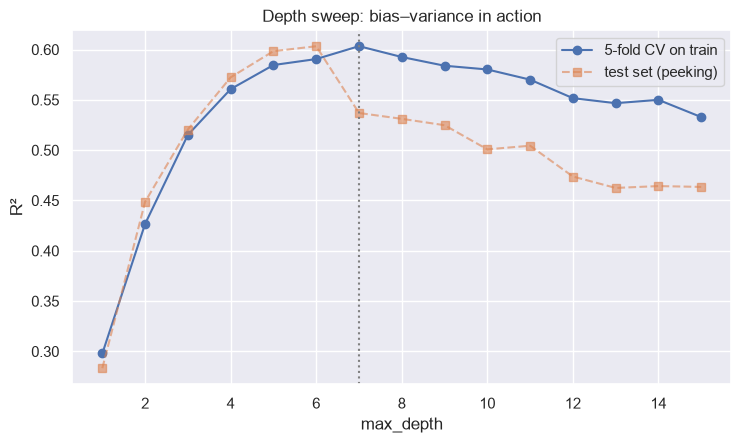

depth-7 tree: test R2=0.537 (unpruned was 0.441)


In [6]:
depths = list(range(1, 16))                          # candidate chain lengths to audition
cv_means, test_scores = [], []                       # one entry per depth
for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    cv = cross_val_score(dt, X_train, y_train, cv=5, scoring="r2")  # 5-fold CV, TRAINING DATA ONLY
    cv_means.append(cv.mean())                       # average fold score = honest estimate
    test_scores.append(dt.fit(X_train, y_train).score(X_test, y_test))  # peek (teaching contrast!)

best_depth = depths[int(np.argmax(cv_means))]       # depth whose CV mean is highest
print(f"best max_depth by CV: {best_depth}  (CV R2={max(cv_means):.3f})")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(depths, cv_means, "o-", label="5-fold CV on train")   # the line we're allowed to select on
ax.plot(depths, test_scores, "s--", alpha=0.6, label="test set (peeking)")  # forbidden for selection
ax.axvline(best_depth, ls=":", c="gray")                      # mark the CV winner
ax.set(xlabel="max_depth", ylabel="R²", title="Depth sweep: bias-variance in action")
ax.legend()
plt.show()

best_depth_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42).fit(X_train, y_train)
print(f"depth-{best_depth} tree: test R2={best_depth_tree.score(X_test, y_test):.3f} "
      f"(unpruned was {unpruned.score(X_test, y_test):.3f})")

## 5. Cost-complexity pruning (`ccp_alpha`) - a smarter scalpel

Depth limits are blunt; cost-complexity pruning grows the full tree first,
then removes whichever branches add less accuracy than the penalty `ccp_alpha`
charges for their existence. `cost_complexity_pruning_path()` returns the
alphas at which branches get cut - we audition a handful of them with CV.

⚠️ Alphas span orders of magnitude, so we plot on a log x-axis and subsample
the path to keep compute sane (10 candidates × 5 folds, not hundreds).

best ccp_alpha: 0.00019   (CV R2=0.562)
pruned tree : leaves=517   test R2=0.454
unpruned    : leaves=3875   test R2=0.441


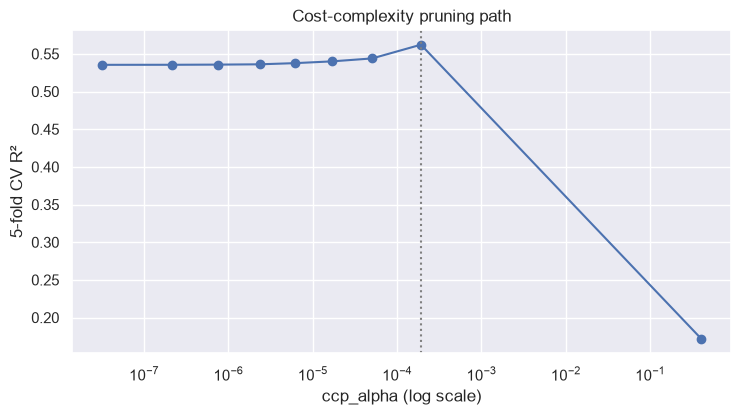

In [7]:
path = unpruned.cost_complexity_pruning_path(X_train, y_train)   # effective alphas for THIS data
alphas = path.ccp_alphas                                         # ascending penalties; last = single leaf
pick_idx = np.unique(np.linspace(0, len(alphas) - 1, 10).astype(int))  # 10 evenly spaced stops
alpha_grid = alphas[pick_idx]                                    # affordable search grid

cv_by_alpha = []
for a in alpha_grid:                                             # audition each penalty honestly
    dt = DecisionTreeRegressor(ccp_alpha=a, random_state=42)
    cv_by_alpha.append(cross_val_score(dt, X_train, y_train, cv=5, scoring="r2").mean())
cv_by_alpha = np.array(cv_by_alpha)

best_alpha = float(alpha_grid[int(np.argmax(cv_by_alpha))])      # penalty with the best CV score
print(f"best ccp_alpha: {best_alpha:.5f}   (CV R2={cv_by_alpha.max():.3f})")

pruned = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42).fit(X_train, y_train)
test_r2_pruned = pruned.score(X_test, y_test)                    # final honest number for the pruned tree
print(f"pruned tree : leaves={pruned.get_n_leaves():3d}   test R2={test_r2_pruned:.3f}")
print(f"unpruned    : leaves={unpruned.get_n_leaves():3d}   test R2={unpruned.score(X_test, y_test):.3f}")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.semilogx(alpha_grid[1:], cv_by_alpha[1:], "o-")               # skip alpha≈0 (undefined on log axis)
ax.axvline(best_alpha, ls=":", c="gray")                         # mark the CV optimum
ax.set(xlabel="ccp_alpha (log scale)", ylabel="5-fold CV R²",
       title="Cost-complexity pruning path")
plt.show()

## 6. Feature importances - what does the pruned tree look at?

Each feature's importance = total SSE reduction it caused across all its
splits, normalised to sum to 1. ⚠️ These are *impurity-based* importances:
fast but biased toward high-cardinality features and features correlated with
strong ones. Treat as hints, not truth (permutation importance is stricter).

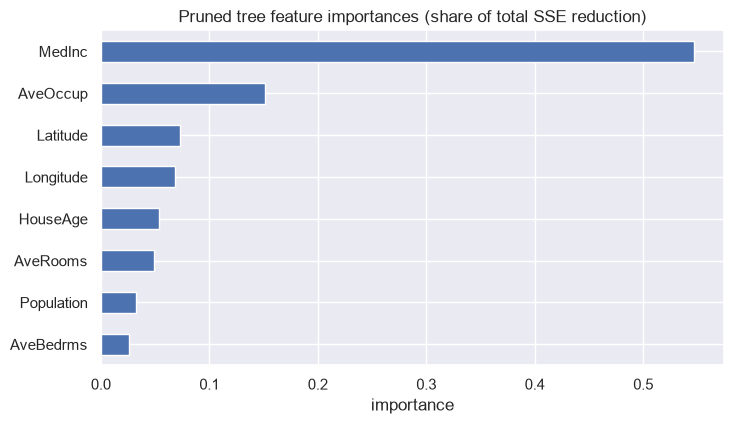

MedInc       0.547
AveOccup     0.151
Latitude     0.073
Longitude    0.068
dtype: float64


In [8]:
importances = pd.Series(pruned.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4.4))
importances.plot.barh(ax=ax)                     # horizontal bars keep long names readable
ax.set_title("Pruned tree feature importances (share of total SSE reduction)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(3).head(4))   # leaderboard print-out

## Summary & key takeaways

- **Unpruned tree = textbook overfit:** ~perfect train fit, visibly worse test;
  the leaf count exposes how much memorizing machinery it built.
- **Depth sweep + 5-fold CV** finds a sweet spot where validation R² peaks -
  the classic bias-variance hump drawn as a curve.
- **`ccp_alpha` pruning** reaches comparable (often better) test performance
  with fewer leaves - a principled, data-driven way to cut weak branches.
- **Importances** summarise where the tree spends its error budget; here
  `MedInc` (median income) dominates, with latitude/longitude adding geography.

💡 Next: try the graded projects in `projects/` - tips 🟢, mpg 🟡,
insurance 🟠, and an underfit-vs-overfit deep dive 🔴.